In [ ]:
"""
Sudoku 4x4 — compare GT and DB contributions.

This file only runs experiments and saves JSON results.
It does NOT plot. Use SECTION 2 as a separate plot_results.py file.

One execution compares all 4 models under the same experimental condition:
  1. enhanced_tf       : no conv / no DB
  2. enhanced_tf_db    : no conv / DB
  3. enhanced_gt       : conv / no DB
  4. enhanced_gt_db    : conv / DB

External sweep variables:
  1. lambda_db   : DB loss weight for *_db models
  2. num_givens  : number of revealed cells, 4–12
  3. num_train   : training set size
  4. sudoku_size : fixed at 4 for now
  5. d_model     : model capacity, 32 | 64 | 128
  6. num_epochs  : training length; default 300

Primary scientific questions:
  - DB effect on Transformer  = enhanced_tf_db - enhanced_tf
  - GT effect                 = enhanced_gt    - enhanced_tf
  - DB effect on GT           = enhanced_gt_db - enhanced_gt
  - Combined GT+DB gain       = enhanced_gt_db - enhanced_tf

Outputs:
  - final_info.json
  - all_results.json
"""

import argparse
import copy
import itertools
import json
import math
import os
import random
import time
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# ── Fixed hyperparameters ────────────────────────────────────────────────────
N_HEADS     = 4
NUM_LAYERS  = 3
DROPOUT     = 0.15
CONV_KERNEL = 5
LR          = 1e-3
BATCH_SIZE  = 32
NUM_VAL     = 200
NUM_TEST    = 200
DATA_SEED   = 42
SEEDS       = [12]


# ─── Reproducibility ─────────────────────────────────────────────────────────

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─── Dataset, 4x4 only for now ───────────────────────────────────────────────

@dataclass
class SudokuInstance:
    puzzle: torch.Tensor    # (N*N,) digits 0..N-1, or -1 for blank
    solution: torch.Tensor  # (N*N,) digits 0..N-1


def _base_solution_4x4():
    return torch.tensor(
        [[0, 1, 2, 3],
         [2, 3, 0, 1],
         [1, 0, 3, 2],
         [3, 2, 1, 0]],
        dtype=torch.long,
    )


def random_sudoku_solution_4x4() -> torch.Tensor:
    M = _base_solution_4x4()

    # Symbol permutation.
    M = torch.randperm(4)[M]

    # Row permutations within 2-row bands.
    r_perm = []
    for band in [[0, 1], [2, 3]]:
        order = band.copy()
        random.shuffle(order)
        r_perm.extend(order)
    M = M[r_perm, :]

    # Swap row bands.
    if random.random() < 0.5:
        M = torch.cat([M[2:], M[:2]], dim=0)

    # Column permutations within 2-column stacks.
    c_perm = []
    for stack in [[0, 1], [2, 3]]:
        order = stack.copy()
        random.shuffle(order)
        c_perm.extend(order)
    M = M[:, c_perm]

    # Swap column stacks.
    if random.random() < 0.5:
        M = torch.cat([M[:, 2:], M[:, :2]], dim=1)

    return M.reshape(-1)


def make_dataset(n: int, num_givens: int, sudoku_size: int) -> List[SudokuInstance]:
    if sudoku_size != 4:
        raise ValueError("Only sudoku_size=4 is currently supported.")
    if not (4 <= num_givens <= 12):
        raise ValueError("num_givens must be in [4, 12] for 4x4 Sudoku.")

    n_cells = sudoku_size * sudoku_size
    ds = []
    for _ in range(n):
        sol = random_sudoku_solution_4x4()
        idxs = list(range(n_cells))
        random.shuffle(idxs)
        given_set = set(idxs[:num_givens])
        puzzle = torch.tensor(
            [sol[i].item() if i in given_set else -1 for i in range(n_cells)],
            dtype=torch.long,
        )
        ds.append(SudokuInstance(puzzle=puzzle, solution=sol.clone()))
    return ds


# ─── Triangles, Diagrammatic Backprop loss, 4x4 ──────────────────────────────

def build_triangles_4x4():
    tris = []
    cid = lambda r, c: r * 4 + c

    # Row triples.
    for r in range(4):
        for t in itertools.combinations([cid(r, c) for c in range(4)], 3):
            tris.append(t)

    # Column triples.
    for c in range(4):
        for t in itertools.combinations([cid(r, c) for r in range(4)], 3):
            tris.append(t)

    # 2x2 box triples.
    for rs, cs in itertools.product([[0, 1], [2, 3]], [[0, 1], [2, 3]]):
        cells = [cid(r, c) for r in rs for c in cs]
        for t in itertools.combinations(cells, 3):
            tris.append(t)

    return tris


_tris_raw = build_triangles_4x4()
# Pre-split into three index tensors for fully vectorized loss — shape (T,)
_TRI_I = torch.tensor([t[0] for t in _tris_raw], dtype=torch.long)
_TRI_J = torch.tensor([t[1] for t in _tris_raw], dtype=torch.long)
_TRI_K = torch.tensor([t[2] for t in _tris_raw], dtype=torch.long)


def triangle_consistency(hT: torch.Tensor) -> torch.Tensor:
    # hT: (B, 16, d) or (16, d)
    if hT.ndim == 2:
        hT = hT.unsqueeze(0)
    dev = hT.device
    ti, tj, tk = _TRI_I.to(dev), _TRI_J.to(dev), _TRI_K.to(dev)
    vi, vj, vk = hT[:, ti, :], hT[:, tj, :], hT[:, tk, :]  # (B, T, d)
    m = (vi + vj + vk) / 3.0
    return ((vi - m).pow(2) + (vj - m).pow(2) + (vk - m).pow(2)).sum(-1).mean()


# ─── Positional encoding ─────────────────────────────────────────────────────

class SinusoidalPE(nn.Module):
    def __init__(self, d_model: int, max_len: int = 16):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# ─── Transformer blocks ──────────────────────────────────────────────────────

class PlainBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, N_HEADS, dropout=DROPOUT, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x):
        a, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(a))
        return self.norm2(x + self.drop(self.mlp(x)))


class ConvBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, N_HEADS, dropout=DROPOUT, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=CONV_KERNEL, padding=CONV_KERNEL // 2)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x):
        a, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(a))
        z = self.conv(x.transpose(1, 2)).transpose(1, 2)[:, :x.size(1)]
        x = self.norm2(x + self.drop(z))
        return self.norm3(x + self.drop(self.mlp(x)))


# ─── Model ───────────────────────────────────────────────────────────────────

class SudokuModel(nn.Module):
    def __init__(self, d_model: int, use_conv: bool, n_digits: int = 4):
        super().__init__()
        self.in_proj = nn.Linear(n_digits + 1, d_model)  # one-hot + given flag
        self.pe = SinusoidalPE(d_model)
        BlockCls = ConvBlock if use_conv else PlainBlock
        self.layers = nn.ModuleList([BlockCls(d_model) for _ in range(NUM_LAYERS)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_digits)
        self.n_digits = n_digits

    def forward(self, puzzle, return_embeddings=False):
        squeeze = puzzle.ndim == 1
        if squeeze:
            puzzle = puzzle.unsqueeze(0)

        digits = puzzle.clone()
        digits[digits == -1] = 0
        x = torch.cat(
            [
                F.one_hot(digits, self.n_digits).float(),
                (puzzle != -1).float().unsqueeze(-1),
            ],
            dim=-1,
        )
        x = self.pe(self.in_proj(x))
        for layer in self.layers:
            x = layer(x)
        hT = self.norm(x)
        logits = self.head(hT)

        if squeeze:
            logits = logits.squeeze(0)
            hT = hT.squeeze(0)
        return (logits, hT) if return_embeddings else logits


MODEL_CONFIGS = {
    "enhanced_tf":    dict(use_conv=False, use_db=False),
    "enhanced_tf_db": dict(use_conv=False, use_db=True),
    "enhanced_gt":    dict(use_conv=True,  use_db=False),
    "enhanced_gt_db": dict(use_conv=True,  use_db=True),
}
MODEL_ORDER = ["enhanced_tf", "enhanced_tf_db", "enhanced_gt", "enhanced_gt_db"]


# ─── Evaluation ──────────────────────────────────────────────────────────────

def evaluate(model, dataset, device, n_digits):
    model.eval()
    puzzles = torch.stack([inst.puzzle for inst in dataset]).to(device)  # (N, 16)
    sols    = torch.stack([inst.solution for inst in dataset]).to(device) # (N, 16)

    with torch.no_grad():
        logits = model(puzzles)                         # (N, 16, n_digits)
        preds  = logits.argmax(-1)                      # (N, 16)
        loss   = F.cross_entropy(logits.view(-1, n_digits), sols.view(-1)).item()

    correct_cells = (preds == sols).sum().item()
    total_cells   = sols.numel()
    full_correct  = (preds == sols).all(dim=1).sum().item()
    n = len(dataset)
    return {
        "cell_acc":   correct_cells / total_cells,
        "puzzle_acc": full_correct / n,
        "loss":       loss,
    }


# ─── Training ────────────────────────────────────────────────────────────────

def train_one_seed(model, train_ds, val_ds, test_ds, device, lambda_db, n_digits, num_epochs):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    uses_db = lambda_db > 0.0

    best_val_puzzle_acc = -1.0
    best_epoch = 1
    best_weights = None
    best_val_metrics = None
    epoch_logs = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        idxs = list(range(len(train_ds)))
        random.shuffle(idxs)
        total_loss, steps = 0.0, 0

        for i in range(0, len(idxs), BATCH_SIZE):
            batch = idxs[i:i + BATCH_SIZE]
            puzzles = torch.stack([train_ds[j].puzzle for j in batch]).to(device)
            sols = torch.stack([train_ds[j].solution for j in batch]).to(device)

            if uses_db:
                logits, hT = model(puzzles, return_embeddings=True)
                loss = (
                    F.cross_entropy(logits.view(-1, n_digits), sols.view(-1))
                    + lambda_db * triangle_consistency(hT)
                )
            else:
                logits = model(puzzles)
                loss = F.cross_entropy(logits.view(-1, n_digits), sols.view(-1))

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        train_loss = total_loss / max(steps, 1)
        val = evaluate(model, val_ds, device, n_digits)

        epoch_logs.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val["loss"],
            "val_cell_acc": val["cell_acc"],
            "val_puzzle_acc": val["puzzle_acc"],
        })

        if val["puzzle_acc"] > best_val_puzzle_acc:
            best_val_puzzle_acc = val["puzzle_acc"]
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            best_val_metrics = val

    model.load_state_dict(best_weights)
    test = evaluate(model, test_ds, device, n_digits)

    return {
        "best_epoch": best_epoch,
        "train_loss_last": train_loss,
        "val_puzzle_acc": best_val_metrics["puzzle_acc"],
        "val_cell_acc": best_val_metrics["cell_acc"],
        "val_loss": best_val_metrics["loss"],
        "test_puzzle_acc": test["puzzle_acc"],
        "test_cell_acc": test["cell_acc"],
        "test_loss": test["loss"],
    }, epoch_logs


# ─── Statistics and effect analysis ──────────────────────────────────────────

def mean_stderr(values):
    values = np.array(values, dtype=float)
    mean = float(values.mean())
    if len(values) > 1:
        stderr = float(values.std(ddof=1) / np.sqrt(len(values)))
    else:
        stderr = 0.0
    return {"means": mean, "stderrs": stderr}


def aggregate_seed_results(seed_results):
    keys = seed_results[0].keys()
    return {key: mean_stderr([r[key] for r in seed_results]) for key in keys}


def compute_effects(model_summaries, metric="test_puzzle_acc"):
    def m(model_name):
        return model_summaries[model_name][metric]["means"]

    effects = {
        "db_effect_on_tf": m("enhanced_tf_db") - m("enhanced_tf"),
        "gt_effect": m("enhanced_gt") - m("enhanced_tf"),
        "db_effect_on_gt": m("enhanced_gt_db") - m("enhanced_gt"),
        "combined_gt_db_gain": m("enhanced_gt_db") - m("enhanced_tf"),
    }
    return {k: {"means": float(v), "stderrs": 0.0} for k, v in effects.items()}


# ─── Main experiment: every run compares all 4 models ────────────────────────

def run_experiment(args):
    device = get_device()
    n_digits = args.sudoku_size

    set_seed(DATA_SEED)
    train_ds = make_dataset(args.num_train, args.num_givens, args.sudoku_size)
    val_ds = make_dataset(NUM_VAL, args.num_givens, args.sudoku_size)
    test_ds = make_dataset(NUM_TEST, args.num_givens, args.sudoku_size)

    final_models: Dict[str, dict] = {}
    all_models: Dict[str, dict] = {}

    for model_name in MODEL_ORDER:
        cfg = MODEL_CONFIGS[model_name]
        model_lambda_db = args.lambda_db if cfg["use_db"] else 0.0

        seed_results = []
        epoch_logs_by_seed = {}

        print(f"\n=== Training {model_name} | lambda_db={model_lambda_db} ===")
        for seed in SEEDS:
            print(f"  seed {seed}")
            set_seed(seed)
            model = SudokuModel(
                d_model=args.d_model,
                use_conv=cfg["use_conv"],
                n_digits=n_digits,
            )
            result, epoch_logs = train_one_seed(
                model=model,
                train_ds=train_ds,
                val_ds=val_ds,
                test_ds=test_ds,
                device=device,
                lambda_db=model_lambda_db,
                n_digits=n_digits,
                num_epochs=args.num_epochs,
            )
            seed_results.append(result)
            epoch_logs_by_seed[f"seed_{seed}"] = epoch_logs

        summary = aggregate_seed_results(seed_results)
        summary["lambda_db_used"] = {"means": model_lambda_db, "stderrs": 0.0}
        summary["use_conv"] = {"means": cfg["use_conv"], "stderrs": ""}
        summary["use_db"] = {"means": cfg["use_db"], "stderrs": ""}
        final_models[model_name] = summary

        all_models[model_name] = {
            "seed_results": seed_results,
            "epoch_logs": epoch_logs_by_seed,
            "summary": summary,
        }

    effects_test_puzzle_acc = compute_effects(final_models, metric="test_puzzle_acc")
    effects_test_cell_acc = compute_effects(final_models, metric="test_cell_acc")

    final_info = {
        # ── Flat top-level metrics (required by AI Scientist's baseline loader) ──
        "best_test_puzzle_acc":  final_models["enhanced_gt_db"]["test_puzzle_acc"],
        "best_test_cell_acc":    final_models["enhanced_gt_db"]["test_cell_acc"],
        "db_effect_on_tf":       effects_test_puzzle_acc["db_effect_on_tf"],
        "gt_effect":             effects_test_puzzle_acc["gt_effect"],
        "db_effect_on_gt":       effects_test_puzzle_acc["db_effect_on_gt"],
        "combined_gt_db_gain":   effects_test_puzzle_acc["combined_gt_db_gain"],
        # ── Full nested structure ─────────────────────────────────────────────────
        "config": {
            "lambda_db": args.lambda_db,
            "num_givens": args.num_givens,
            "num_train": args.num_train,
            "sudoku_size": args.sudoku_size,
            "d_model": args.d_model,
            "num_epochs": args.num_epochs,
            "seeds": SEEDS,
            "num_val": NUM_VAL,
            "num_test": NUM_TEST,
        },
        "models": final_models,
        "effects_test_puzzle_acc": effects_test_puzzle_acc,
        "effects_test_cell_acc": effects_test_cell_acc,
    }

    all_results = {
        "config": final_info["config"],
        "models": all_models,
    }

    return final_info, all_results


# ─── Entry point ─────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument("--out_dir", type=str, default="run_0")

    parser.add_argument("--lambda_db", type=float, default=0.05,
                        help="DB loss weight for enhanced_tf_db and enhanced_gt_db")
    parser.add_argument("--num_givens", type=int, default=8,
                        help="Revealed cells per puzzle, must be in [4, 12]")
    parser.add_argument("--num_train", type=int, default=333,
                        help="Training set size")
    parser.add_argument("--sudoku_size", type=int, default=4, choices=[4],
                        help="Grid size; currently only 4x4 is supported")
    parser.add_argument("--d_model", type=int, default=64, choices=[32, 64, 128],
                        help="Embedding dimension")
    parser.add_argument("--num_epochs", type=int, default=4000,
                        help="Training epochs; default 300 for stronger final runs")

    # For terminal / AI-Scientist, parse_args() is stricter.
    # For Colab/Jupyter cells, parse_known_args() avoids kernel argument errors.
    args, _ = parser.parse_known_args()

    os.makedirs(args.out_dir, exist_ok=True)
    start = time.time()

    final_info, all_results = run_experiment(args)
    final_info["runtime_seconds"] = {"means": float(time.time() - start), "stderrs": 0.0}

    with open(os.path.join(args.out_dir, "final_info.json"), "w") as f:
        json.dump(final_info, f, indent=2)
    with open(os.path.join(args.out_dir, "all_results.json"), "w") as f:
        json.dump(all_results, f, indent=2)

    print("\n=== Final summary ===")
    print(json.dumps(final_info, indent=2))
    print(f"\nSaved JSON outputs to: {args.out_dir}")


if __name__ == "__main__":
    main()


=== Training enhanced_tf | lambda_db=0.0 ===
  seed 12

=== Training enhanced_tf_db | lambda_db=0.05 ===
  seed 12

=== Training enhanced_gt | lambda_db=0.0 ===
  seed 12

=== Training enhanced_gt_db | lambda_db=0.05 ===
  seed 12

=== Final summary ===
{
  "best_test_puzzle_acc": {
    "means": 0.85,
    "stderrs": 0.0
  },
  "best_test_cell_acc": {
    "means": 0.97125,
    "stderrs": 0.0
  },
  "db_effect_on_tf": {
    "means": 0.20999999999999996,
    "stderrs": 0.0
  },
  "gt_effect": {
    "means": 0.07999999999999996,
    "stderrs": 0.0
  },
  "db_effect_on_gt": {
    "means": -0.010000000000000009,
    "stderrs": 0.0
  },
  "combined_gt_db_gain": {
    "means": 0.06999999999999995,
    "stderrs": 0.0
  },
  "config": {
    "lambda_db": 0.05,
    "num_givens": 8,
    "num_train": 333,
    "sudoku_size": 4,
    "d_model": 64,
    "num_epochs": 4000,
    "seeds": [
      12
    ],
    "num_val": 200,
    "num_test": 200
  },
  "models": {
    "enhanced_tf": {
      "best_epoch": 

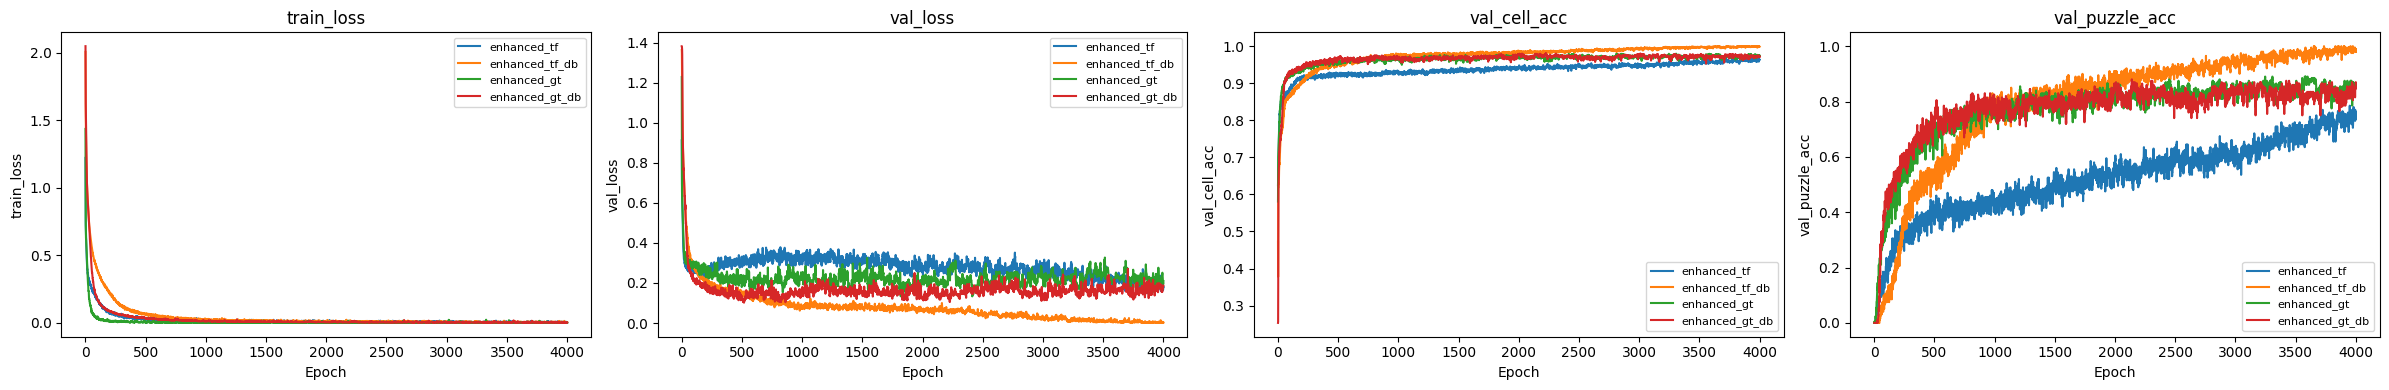

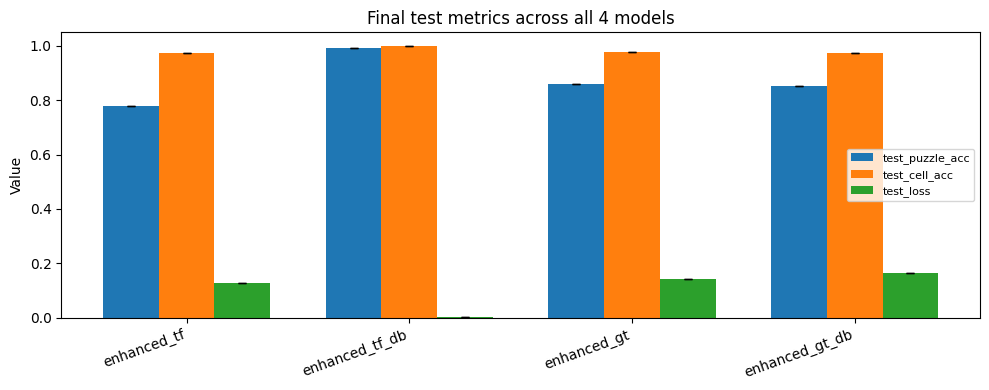

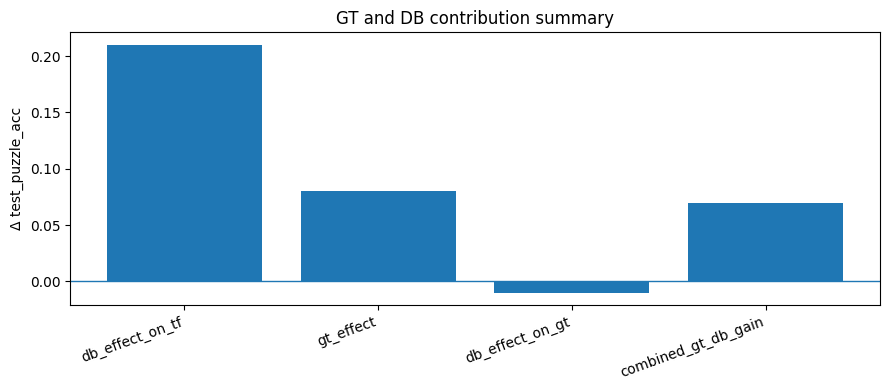

Saved plots to: run_0


In [ ]:
"""
plot_results.py

Read final_info.json and all_results.json generated by experiment.py,
then create comparison plots for all four models.

Inputs:
  - final_info.json
  - all_results.json

Outputs:
  - comparison_curves_one_row.png
  - final_test_metrics_from_saved.png
  - contribution_summary_from_saved.png
"""

# Save the following as plot_results.py if you want a separate plotting file.


import argparse
import json
import os

import numpy as np
import matplotlib.pyplot as plt


MODEL_ORDER = ["enhanced_tf", "enhanced_tf_db", "enhanced_gt", "enhanced_gt_db"]


def plot_saved_comparison(out_dir="run_0"):
    final_path = os.path.join(out_dir, "final_info.json")
    results_path = os.path.join(out_dir, "all_results.json")

    with open(final_path, "r") as f:
        final_info = json.load(f)
    with open(results_path, "r") as f:
        all_results = json.load(f)

    # 1) Training/validation curves in one row.
    curve_metrics = ["train_loss", "val_loss", "val_cell_acc", "val_puzzle_acc"]
    fig, axes = plt.subplots(1, 4, figsize=(24, 4))

    for ax, metric in zip(axes, curve_metrics):
        for model_name in MODEL_ORDER:
            epoch_logs_by_seed = all_results["models"][model_name]["epoch_logs"]
            first_logs = next(iter(epoch_logs_by_seed.values()))
            epochs = [row["epoch"] for row in first_logs]

            values = []
            for logs in epoch_logs_by_seed.values():
                values.append([row[metric] for row in logs])
            values = np.array(values, dtype=float)

            mean = values.mean(axis=0)
            if values.shape[0] > 1:
                stderr = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0])
            else:
                stderr = np.zeros_like(mean)

            ax.plot(epochs, mean, label=model_name)
            ax.fill_between(epochs, mean - stderr, mean + stderr, alpha=0.12)

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend(fontsize=8)

    plt.tight_layout()
    save_path = os.path.join(out_dir, "comparison_curves_one_row.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    # 2) Final test metrics.
    final_metrics = ["test_puzzle_acc", "test_cell_acc", "test_loss"]
    labels = MODEL_ORDER
    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(10, 4))
    for j, metric in enumerate(final_metrics):
        means = [final_info["models"][m][metric]["means"] for m in labels]
        errors = [final_info["models"][m][metric]["stderrs"] for m in labels]
        plt.bar(x + (j - 1) * width, means, width, yerr=errors, capsize=3, label=metric)

    plt.xticks(x, labels, rotation=20, ha="right")
    plt.ylabel("Value")
    plt.title("Final test metrics across all 4 models")
    plt.legend(fontsize=8)
    plt.tight_layout()
    save_path = os.path.join(out_dir, "final_test_metrics_from_saved.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    # 3) Contribution summary from test_puzzle_acc.
    effects = final_info["effects_test_puzzle_acc"]
    effect_names = list(effects.keys())
    effect_values = [effects[k]["means"] for k in effect_names]

    plt.figure(figsize=(9, 4))
    plt.bar(effect_names, effect_values)
    plt.axhline(0, linewidth=1)
    plt.ylabel("Δ test_puzzle_acc")
    plt.title("GT and DB contribution summary")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    save_path = os.path.join(out_dir, "contribution_summary_from_saved.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"Saved plots to: {out_dir}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--out_dir", type=str, default="run_0")
    args, _ = parser.parse_known_args()
    plot_saved_comparison(args.out_dir)


if __name__ == "__main__":
    main()